# Dense-phase CO₂ decompression and the fluid loading behind fracture arrest

**A detailed NeqSim research and teaching notebook for [equinor/neqsim#3750](https://github.com/equinor/neqsim/issues/3750).**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/co2_decompression_fracture_arrest_paper.ipynb)

**Research question:** How do the equation of state, initial temperature and light impurities change the decompression response of dense-phase CO₂, and which parts of a fracture-arrest assessment can these calculations support?

Inspired by Andreas Mondry and Christoph Bosch (2024), *New Aspects on Modeling Ductile Fracture Arrest Performance of Large-Diameter Pipes in Dense-Phase Carbon Dioxide*, ASME IPC2024-132853, [DOI: 10.1115/IPC2024-132853](https://doi.org/10.1115/IPC2024-132853).

The saved outputs are calculated with source-built NeqSim master at `0852741babb7601304c70d10528e8de562bdf0be` (inspected 17 September 2026). Inputs are synthetic teaching cases. The accessible publisher abstract establishes the paper's scope; the full paper and its numerical burst-test dataset were not available for this work. **This notebook is a thermodynamic companion, not a numerical reproduction of that paper or a qualified fracture-arrest design.**

### What you will learn

1. Separate fluid decompression from steel fracture resistance and fluid–structure coupling.
2. Construct and audit dense-phase CO₂ fluids with NeqSim PR and SRK equations of state.
3. Compare pure-CO₂ properties with the independent Span–Wagner reference EOS in CoolProp.
4. Calculate pressure–entropy and pressure–enthalpy paths, equilibrium acoustic speed and a simple-wave decompression characteristic.
5. Quantify nitrogen/hydrogen enrichment and the sensitivity to initial temperature and composition.
6. Translate pressure to a transparent elastic hoop-stress scale, without inferring toughness or arrest.
7. Audit native APIs, residuals, numerical sensitivity and the data still needed for a research benchmark.

**Run order:** Runtime → reference checks → decompression → impurities → loading → API appendix → validation/export. Run all cells from a fresh runtime. First-time Java compilation may take several minutes.

## 1. Reading the paper and setting an honest comparison boundary

The publisher-deposited abstract describes a numerical fracture-arrest model calibrated against published full-scale CO₂ burst tests. It explores pipe diameter and wall-thickness/diameter ratio, questions the usefulness of Charpy energy alone for modern high-toughness steels, and reports consistency with a DNV RP F104 assessment. These are the authors' statements, not validations performed here. [Publisher record](https://asmedigitalcollection.asme.org/IPC/proceedings/IPC2024/88582/V005T09A009/1210789); [publisher-deposited Crossref abstract](https://api.crossref.org/works/10.1115/IPC2024-132853).

| Paper-related question | Executed here | Evidence boundary |
|---|---|---|
| How does dense CO₂ expand and flash? | NeqSim equilibrium thermodynamics and path calculations | Equilibrium, fixed overall composition, no solid CO₂ |
| How does decompression propagate? | One-dimensional inviscid simple-wave characteristic | No finite pipe, friction, heat transfer, nucleation delay or moving crack |
| How do impurities alter loading? | 0–3 mol% N₂ sensitivity and a 2 mol% H₂ scenario | Synthetic compositions; no mixture experimental calibration |
| What is the role of diameter and thickness? | Elastic hoop-stress scale and inventory | No plasticity, fracture toughness, crack speed or arrest prediction |
| Can the paper's burst tests be reproduced? | A benchmark data contract and validation plan | Numerical test records and model details still required |

The automated issue suggests `CO2InjectionWellAnalyzer` and `TransientWellbore`. Those are useful **adjacent CCS screening tools**, but their current implementations do not solve this paper's fracture problem. We demonstrate the latter's prescribed cooling law in an appendix and use `ImpurityMonitor`, named streams and `ProcessSystem` for composable examples.

## 2. Reproducible Colab runtime

The Python packages provide arrays, plotting, root solving, a Java bridge and an independent CO₂ reference. Java calculations use the source-built NeqSim JAR, not the JAR bundled in a released Python wheel. The source revision is pinned to the inspected master commit for reproducibility; changing it creates a new validation case.

The optional local-validation inputs `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` must identify this same commit and its built JAR. The notebook verifies commit identity, records the JAR hash and checks Java class origins. Build logs are retained on failure. A rerun after starting another JVM requires a runtime restart.

In [1]:
import importlib.metadata as metadata
import importlib.util
import subprocess
import sys

requirements = {
    "jpype": "JPype1==1.7.1",
    "numpy": "numpy==2.3.5",
    "pandas": "pandas==2.2.3",
    "matplotlib": "matplotlib==3.10.8",
    "scipy": "scipy==1.17.0",
    "CoolProp": "CoolProp==8.0.0",
}
missing = [
    requirement
    for module, requirement in requirements.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Python:", sys.version.split()[0])
for requirement in requirements.values():
    package = requirement.split("==")[0]
    print(f"{package}: {metadata.version(package)}")

Python: 3.12.14
JPype1: 1.7.1
numpy: 2.3.5
pandas: 2.2.3
matplotlib: 3.10.8
scipy: 1.17.0
CoolProp: 8.0.0


In [2]:
import hashlib
import json
import os
from pathlib import Path
from urllib.parse import unquote, urlparse

NEQSIM_SOURCE_REF = "0852741babb7601304c70d10528e8de562bdf0be"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-source")).resolve()
source_jar_env = os.environ.get("NEQSIM_SOURCE_JAR")
if not source_root.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/equinor/neqsim.git",
            str(source_root),
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    subprocess.run(
        ["git", "-C", str(source_root), "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
        check=True,
        capture_output=True,
        text=True,
    )
    subprocess.run(
        ["git", "-C", str(source_root), "checkout", "--detach", NEQSIM_SOURCE_REF],
        check=True,
        capture_output=True,
        text=True,
    )
resolved_commit = subprocess.check_output(
    ["git", "-C", str(source_root), "rev-parse", "HEAD"],
    text=True,
).strip()
assert resolved_commit == NEQSIM_SOURCE_REF, "Source checkout differs from the validated ref"
tracked_diff = subprocess.check_output(
    ["git", "-C", str(source_root), "status", "--porcelain", "--untracked-files=no"],
    text=True,
)
assert not tracked_diff.strip(), "Use an unmodified source checkout"
if source_jar_env:
    source_jar = Path(source_jar_env).resolve()
else:
    build_command = [
        "bash",
        "mvnw",
        "-q",
        "-DskipTests",
        "-Dmaven.test.skip=true",
        "-Dcheckstyle.skip",
        "-Dspotless.skip=true",
        "-Dmaven.javadoc.skip=true",
        "package",
    ]
    build_log = Path("neqsim-build.log").resolve()
    with build_log.open("w") as log:
        result = subprocess.run(build_command, cwd=source_root, stdout=log, stderr=log)
    if result.returncode:
        raise RuntimeError(f"NeqSim source build failed. Inspect {build_log}")
    candidates = [
        p
        for p in (source_root / "target").glob("neqsim-*.jar")
        if not p.name.endswith(("-sources.jar", "-javadoc.jar"))
    ]
    assert len(candidates) == 1, candidates
    source_jar = candidates[0].resolve()
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
import jpype

assert not jpype.isJVMStarted(), "Restart runtime before changing the Java classpath"
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xmx2g", convertStrings=True)
class_names = [
    "neqsim.thermo.system.SystemPrEos",
    "neqsim.process.equipment.pipeline.CO2InjectionWellAnalyzer",
    "neqsim.process.measurementdevice.ImpurityMonitor",
]
for class_name in class_names:
    java_class = jpype.JClass(class_name)
    origin = str(java_class.class_.getProtectionDomain().getCodeSource().getLocation())
    assert Path(unquote(urlparse(origin).path)).resolve() == source_jar, origin
provenance = {
    "source_commit": resolved_commit,
    "jar_sha256": jar_sha256,
    "java_version": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python_version": sys.version.split()[0],
    "class_origins_verified": len(class_names),
}
print(json.dumps(provenance, indent=2))

{
  "source_commit": "0852741babb7601304c70d10528e8de562bdf0be",
  "jar_sha256": "bb6dda2fa0cb134dd43106095bbfee8daaba1bbef746e3744071454adae7acd3",
  "java_version": "17.0.20",
  "python_version": "3.12.14",
  "class_origins_verified": 3
}


## 3. Model definitions, units and acceptance criteria

All pressures are **absolute bara**, converted to Pa for derivatives and wave integrals. Temperature inputs are °C; Java constructors use K. Composition is a mole fraction. The expansion keeps the total amount and overall composition fixed, while phase amounts and compositions equilibrate. Gas phase fraction is molar, not volumetric, and is reported only when two phases coexist. A single dense phase can carry NeqSim’s internal gas label; that label is not a vapor quality. Single-phase quality is therefore left undefined in the tables and plots.

The principal model is **Peng–Robinson (PR), classical mixing rule 2 with NeqSim's database binary interaction parameters**. SRK is included as a model-choice comparison. We disable volume correction and use EOS density consistently with EOS entropy and pressure derivatives. Mixing a corrected liquid density with uncorrected caloric derivatives could violate the acoustic identity. No interaction parameter is fitted to the desired result.

Synthetic baseline: 150 bara, 25 °C, pure CO₂; mixture scenarios contain 2 mol% N₂ or H₂. These are sensitivity examples, not capture-stream specifications. The pressure grid stops at 10 bara, and calculations reject temperatures below 220 K. Dry ice, water, hydrates, corrosion and chemical reactions are outside this model.

**Numerical checks:** entropy residual below 0.002 J/(kg K); positive compressibility; normalized phase fractions and component closure; finite-difference sensitivity below 1% at selected smooth states; quadrature convergence below 2 m/s; ideal-gas wave-integral error below 0.02 m/s. EOS-to-reference differences are reported, rather than hidden behind a loose “validated” tolerance.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import brentq
from CoolProp.CoolProp import PropsSI

SystemPR = jpype.JClass("neqsim.thermo.system.SystemPrEos")
SystemSRK = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
ThermoOps = jpype.JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
ImpurityMonitor = jpype.JClass("neqsim.process.measurementdevice.ImpurityMonitor")
TransientWellbore = jpype.JClass("neqsim.process.equipment.pipeline.TransientWellbore")

plt.rcParams.update(
    {
        "figure.dpi": 125,
        "font.size": 10,
        "axes.grid": True,
        "grid.alpha": 0.22,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 5)
checks = []


def check(name, condition, value):
    assert bool(condition), f"{name}: {value}"
    checks.append({"Check": name, "Result": "PASS", "Evidence": str(value)})


def make_fluid(composition, temperature_c=25.0, pressure_bara=150.0, eos="PR"):
    assert abs(sum(composition.values()) - 1.0) < 1e-12
    assert min(composition.values()) > 0.0
    system_class = SystemPR if eos == "PR" else SystemSRK
    fluid = system_class(float(temperature_c + 273.15), float(pressure_bara))
    for component, fraction in composition.items():
        fluid.addComponent(component, float(fraction))
    fluid.setMixingRule(2)
    fluid.useVolumeCorrection(False)
    ThermoOps(fluid).TPflash()
    fluid.init(3)
    return fluid


def eos_density(fluid):
    mass_kg = fluid.getTotalNumberOfMoles() * fluid.getMolarMass()
    return mass_kg / fluid.getVolume("m3")


def snapshot(fluid):
    gas_fraction = np.nan
    if fluid.getNumberOfPhases() > 1 and fluid.hasPhaseType("gas"):
        gas_fraction = fluid.getBeta(fluid.getPhaseNumberOfPhase("gas"))
    return {
        "P_bara": fluid.getPressure(),
        "T_C": fluid.getTemperature() - 273.15,
        "rho_kg_m3": eos_density(fluid),
        "gas_mol_fraction": gas_fraction,
        "phases": fluid.getNumberOfPhases(),
        "s_J_kgK": fluid.getEntropy("J/kgK"),
        "h_J_kg": fluid.getEnthalpy("J/kg"),
    }


compositions = {
    "Pure CO2": {"CO2": 1.0},
    "2% N2": {"CO2": 0.98, "nitrogen": 0.02},
    "2% H2": {"CO2": 0.98, "hydrogen": 0.02},
}
initial_fluids = {name: make_fluid(comp) for name, comp in compositions.items()}
initial_table = pd.DataFrame({name: snapshot(f) for name, f in initial_fluids.items()}).T
check("All starting fluids single phase", (initial_table.phases == 1).all(), 3)
display(initial_table)

,P_bara,T_C,rho_kg_m3,gas_mol_fraction,phases,s_J_kgK,h_J_kg
Pure CO2,150.0,25.0,867.59240,NaN,1.0,-1537.95172,-237427.46927
2% N2,150.0,25.0,840.04218,NaN,1.0,-1509.22090,-230281.20837
2% H2,150.0,25.0,828.82694,NaN,1.0,-1520.90850,-230405.96477


## 4. Independent pure-CO₂ reference: quantify EOS choice first

[CoolProp's CO₂ documentation](https://coolprop.org/fluid_properties/fluids/CarbonDioxide.html) identifies the Span–Wagner EOS as its pure-fluid reference. Here `HEOS::CO2` is an independent software/EOS comparison, **not experimental data**. Compare density and single-phase acoustic speed at six common states. Near-critical extrapolation from this small grid is not justified.

$$\delta_q=100\frac{q_{\mathrm{NeqSim}}-q_{\mathrm{reference}}}{q_{\mathrm{reference}}}$$

Here $q$ is density in kg/m³ or acoustic speed in m/s; the deviation is percent. An EOS can reproduce density fairly closely and still have appreciable derivative-property errors. Acoustic speed is directly relevant to a decompression characteristic.

,EOS,T_C,P_bara,rho_kg_m3,rho_ref,c_m_s,c_ref,rho_error_pct,c_error_pct
0,PR,10,100,916.278,920.456,475.370,563.692,-0.454,-15.669
1,SRK,10,100,815.034,920.456,487.968,563.692,-11.453,-13.434
2,PR,25,100,780.880,817.627,392.543,432.314,-4.494,-9.200
3,SRK,25,100,700.354,817.627,407.974,432.314,-14.343,-5.630
4,PR,25,150,867.592,876.473,456.226,530.041,-1.013,-13.926
5,SRK,25,150,777.630,876.473,473.446,530.041,-11.277,-10.678
6,PR,40,100,563.946,628.612,298.995,269.891,-10.287,10.784
7,SRK,40,100,518.739,628.612,314.850,269.891,-17.479,16.658
8,PR,40,150,747.768,780.233,391.735,427.385,-4.161,-8.342
9,SRK,40,150,677.273,780.233,410.689,427.385,-13.196,-3.907


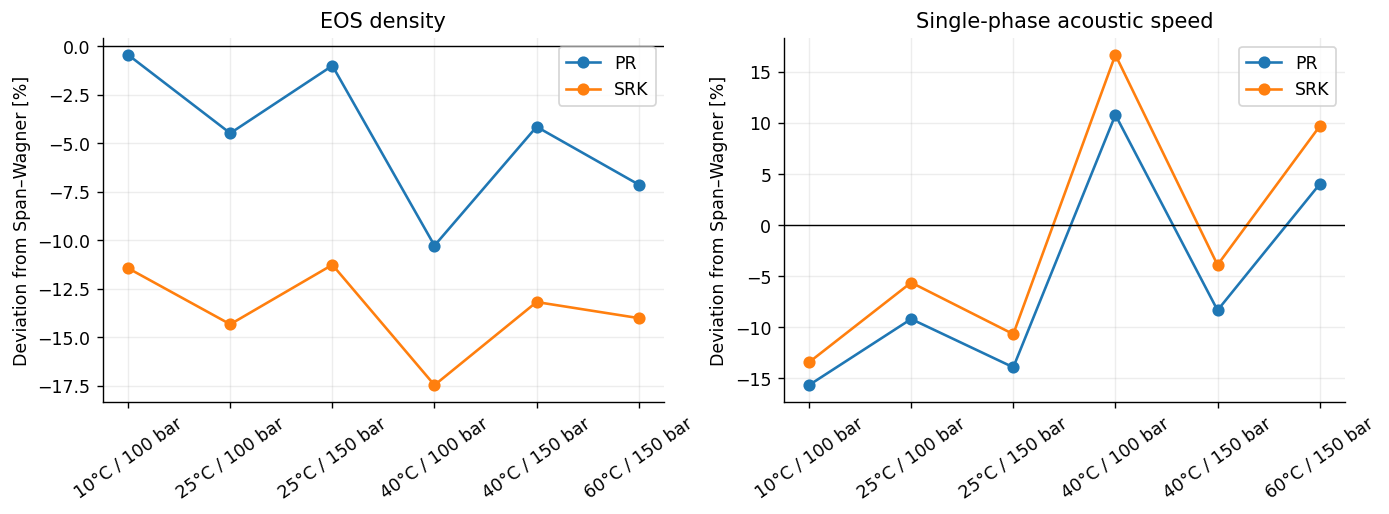

In [4]:
reference_rows = []
for temperature_c, pressure_bara in [
    (10, 100),
    (25, 100),
    (25, 150),
    (40, 100),
    (40, 150),
    (60, 150),
]:
    reference_density = PropsSI(
        "Dmass", "T", temperature_c + 273.15, "P", pressure_bara * 1e5, "HEOS::CO2"
    )
    reference_sound = PropsSI(
        "A", "T", temperature_c + 273.15, "P", pressure_bara * 1e5, "HEOS::CO2"
    )
    for eos in ["PR", "SRK"]:
        fluid = make_fluid({"CO2": 1.0}, temperature_c, pressure_bara, eos)
        assert fluid.getNumberOfPhases() == 1
        density = eos_density(fluid)
        sound = fluid.getSoundSpeed()
        reference_rows.append(
            {
                "EOS": eos,
                "T_C": temperature_c,
                "P_bara": pressure_bara,
                "rho_kg_m3": density,
                "rho_ref": reference_density,
                "c_m_s": sound,
                "c_ref": reference_sound,
                "rho_error_pct": 100 * (density / reference_density - 1),
                "c_error_pct": 100 * (sound / reference_sound - 1),
            }
        )
reference_table = pd.DataFrame(reference_rows)
display(reference_table.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for eos, group in reference_table.groupby("EOS", sort=False):
    labels = [f"{int(row.T_C)}°C / {int(row.P_bara)} bar" for row in group.itertuples()]
    axes[0].plot(labels, group.rho_error_pct, "o-", label=eos)
    axes[1].plot(labels, group.c_error_pct, "o-", label=eos)
for axis, title in zip(axes, ["EOS density", "Single-phase acoustic speed"]):
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set(title=title, ylabel="Deviation from Span–Wagner [%]")
    axis.tick_params(axis="x", rotation=35)
    axis.legend()
plt.show()

## 5. Two different expansion paths

An early rarefaction in a long pipe is often idealized as locally adiabatic and reversible before friction, wall heat transfer and irreversible phase relaxation are introduced. Its thermodynamic path is approximately isentropic. A steady insulated throttling valve has an approximately isenthalpic path when changes in kinetic and potential energy are neglected.

$$s(p,T,\mathbf{z})=s_0\qquad\text{(isentropic path)}$$

$$h(p,T,\mathbf{z})=h_0\qquad\text{(throttling path)}$$

Specific entropy $s$ has units J/(kg K); specific enthalpy $h$ has units J/kg; $\mathbf{z}$ is the overall mole-fraction vector. Neither path alone gives pressure versus time in a ruptured pipeline. A valve path must not be substituted for a decompression wave.

### A native PS-flash regression and an explicit workaround

The source version used here can return two-phase CO₂-mixture states that miss the requested entropy. This is tracked in [NeqSim #3751](https://github.com/equinor/neqsim/issues/3751). We retain the failed residual as diagnostic evidence. Accepted mixture states are instead obtained by a bracketed scalar temperature solve around fresh NeqSim TP flashes. Pure CO₂ first uses the native single-component PS flash, which handles changing phase amount at saturation. Near phase entry, a native pure-fluid call can also miss entropy closure; rejected points are retried with the TP root and accepted only if the entropy postcondition passes. A TP root cannot represent a pure-fluid two-phase entropy interval, so a residual failure there stops execution.

The mixture root is bracketed between 220 and 360 K for these cases. A state outside that bracket fails explicitly. Every state is checked after solving; no failed point is replaced by an invented single-phase state.

In [5]:
ENTROPY_TOLERANCE = 0.002


def isentropic_state(base, pressure_bara):
    target_entropy = base.getEntropy("J/kgK")
    native_accepted = False
    if base.getNumberOfComponents() == 1:
        fluid = base.clone()
        fluid.setPressure(float(pressure_bara))
        ThermoOps(fluid).PSflash(target_entropy, "J/kgK")
        fluid.init(3)
        native_accepted = abs(fluid.getEntropy("J/kgK") - target_entropy) < ENTROPY_TOLERANCE
    if not native_accepted:

        def at_temperature(temperature_k):
            trial = base.clone()
            trial.setPressure(float(pressure_bara))
            trial.setTemperature(float(temperature_k))
            ThermoOps(trial).TPflash()
            trial.init(3)
            return trial

        def residual(temperature_k):
            return at_temperature(temperature_k).getEntropy("J/kgK") - target_entropy

        temperature_k = brentq(residual, 220.0, 360.0, xtol=1e-8)
        fluid = at_temperature(temperature_k)
    entropy_error = fluid.getEntropy("J/kgK") - target_entropy
    assert abs(entropy_error) < ENTROPY_TOLERANCE, entropy_error
    assert 220.0 < fluid.getTemperature() < 360.0
    assert abs(fluid.getPressure() - pressure_bara) < 1e-8
    assert eos_density(fluid) > 0
    return fluid


native_trial = initial_fluids["2% N2"].clone()
native_trial.setPressure(50.0)
ThermoOps(native_trial).PSflash(initial_fluids["2% N2"].getEntropy("J/kgK"), "J/kgK")
native_trial.init(3)
corrected_trial = isentropic_state(initial_fluids["2% N2"], 50.0)
residual_table = pd.DataFrame(
    [
        {
            "Method": method,
            **snapshot(fluid),
            "entropy_residual": fluid.getEntropy("J/kgK")
            - initial_fluids["2% N2"].getEntropy("J/kgK"),
        }
        for method, fluid in [
            ("Native PSflash — diagnostic only", native_trial),
            ("Bracketed TP root — used below", corrected_trial),
        ]
    ]
)
display(residual_table[["Method", "P_bara", "T_C", "rho_kg_m3", "entropy_residual"]])
check(
    "Mixture workaround entropy closure",
    abs(residual_table.entropy_residual.iloc[1]) < ENTROPY_TOLERANCE,
    residual_table.entropy_residual.iloc[1],
)

,Method,P_bara,T_C,rho_kg_m3,entropy_residual
0,Native PSflash — diagnostic only,50.0,11.06025,348.03200,1.82492e+02
1,Bracketed TP root — used below,50.0,8.10682,642.53101,-5.47107e-09


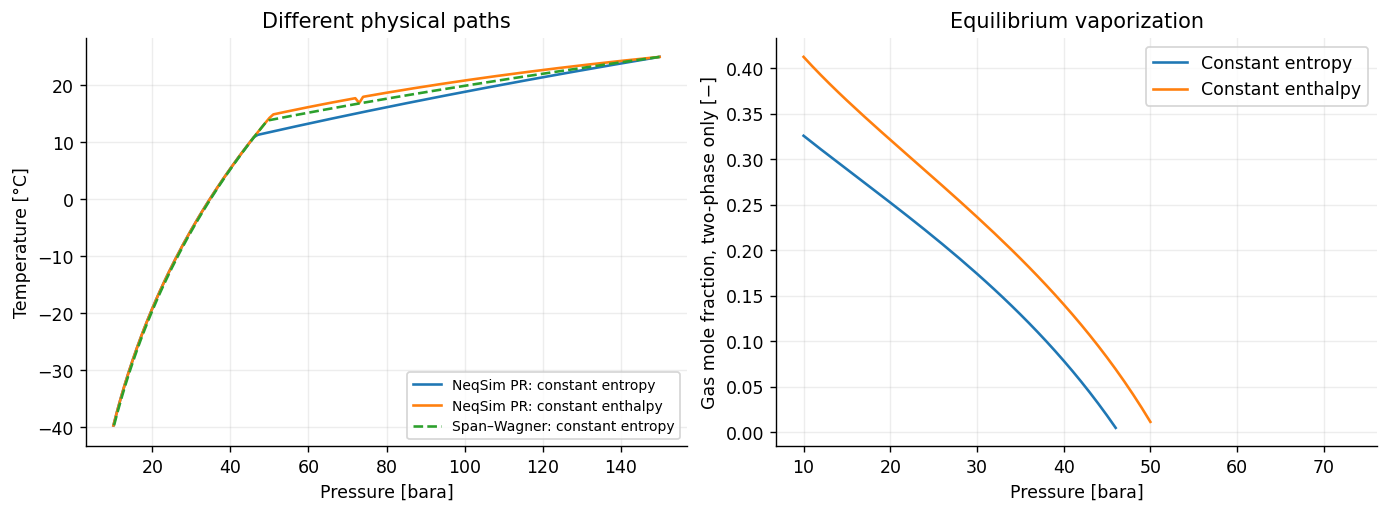

,P_bara,T_C,rho_kg_m3,gas_mol_fraction,phases,s_J_kgK,h_J_kg
0,150.0,25.0000,867.5924,NaN,1,-1537.9517,-237427.4693
20,130.0,22.6396,857.7402,NaN,1,-1537.9517,-239745.7770
40,110.0,20.1550,847.3629,NaN,1,-1537.9517,-242091.5779
60,90.0,17.5303,836.3946,NaN,1,-1537.9517,-244467.1029
80,70.0,14.7455,824.7547,NaN,1,-1537.9517,-246874.9404
100,50.0,11.7758,812.3433,NaN,1,-1537.9517,-249318.1290
120,30.0,-5.2983,334.3896,0.1743,2,-1537.9517,-253006.1878
140,10.0,-39.7047,75.7013,0.3260,2,-1537.9517,-265602.1770


In [6]:
pressures = np.linspace(150.0, 10.0, 141)
pure_base = initial_fluids["Pure CO2"]
pure_states = [isentropic_state(pure_base, pressure) for pressure in pressures]
pure_path = pd.DataFrame([snapshot(fluid) for fluid in pure_states])
enthalpy_target = pure_base.getEnthalpy("J/kg")
throttle_rows = []
for pressure in pressures:
    fluid = pure_base.clone()
    fluid.setPressure(float(pressure))
    ThermoOps(fluid).PHflash(enthalpy_target, "J/kg")
    fluid.init(3)
    assert abs(fluid.getEnthalpy("J/kg") - enthalpy_target) < 0.1
    throttle_rows.append(snapshot(fluid))
throttle_path = pd.DataFrame(throttle_rows)
reference_entropy = PropsSI("Smass", "T", 298.15, "P", 150e5, "HEOS::CO2")
reference_temperature = np.array(
    [
        PropsSI("T", "P", pressure * 1e5, "Smass", reference_entropy, "HEOS::CO2") - 273.15
        for pressure in pressures
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(pressures, pure_path.T_C, label="NeqSim PR: constant entropy")
axes[0].plot(pressures, throttle_path.T_C, label="NeqSim PR: constant enthalpy")
axes[0].plot(pressures, reference_temperature, "--", label="Span–Wagner: constant entropy")
axes[0].set(xlabel="Pressure [bara]", ylabel="Temperature [°C]", title="Different physical paths")
axes[0].legend(fontsize=8)
axes[1].plot(pressures, pure_path.gas_mol_fraction, label="Constant entropy")
axes[1].plot(pressures, throttle_path.gas_mol_fraction, label="Constant enthalpy")
axes[1].set(
    xlabel="Pressure [bara]",
    ylabel="Gas mole fraction, two-phase only [−]",
    title="Equilibrium vaporization",
)
axes[1].legend()
plt.show()
display(pure_path.iloc[::20].round(4))

## 6. Equilibrium acoustic speed is a derivative, not a phase-speed average

For a homogeneous equilibrium model (HEM), phase change and phase composition respond instantly to an infinitesimal disturbance. Its acoustic speed follows the derivative of **total equilibrium density at fixed specific entropy and overall composition**:

$$c_{\mathrm{eq}}^2=\left(\frac{\partial p}{\partial\rho}\right)_{s,\mathbf{z}}\approx\frac{2\Delta p}{\rho(p+\Delta p,s_0)-\rho(p-\Delta p,s_0)}$$

Here $p$ and $\Delta p$ are Pa, $\rho$ is kg/m³, and $c_{\mathrm{eq}}$ is m/s. We use 0.01 bar for the central difference and test smaller/larger increments below. A derivative whose stencil crosses a phase boundary is a smeared transition value; it must not be mistaken for a smooth local derivative.

The inspected `SystemThermo.getSoundSpeed()` is a mole-fraction-weighted average of phase acoustic speeds. That quantity agrees with the derivative in a single phase but is **not** the equilibrium two-phase sound speed. The curves below make the distinction visible. Finite-rate vaporization and nucleation can give a different physical response from HEM; these calculations do not establish which relaxation model matches a burst test.

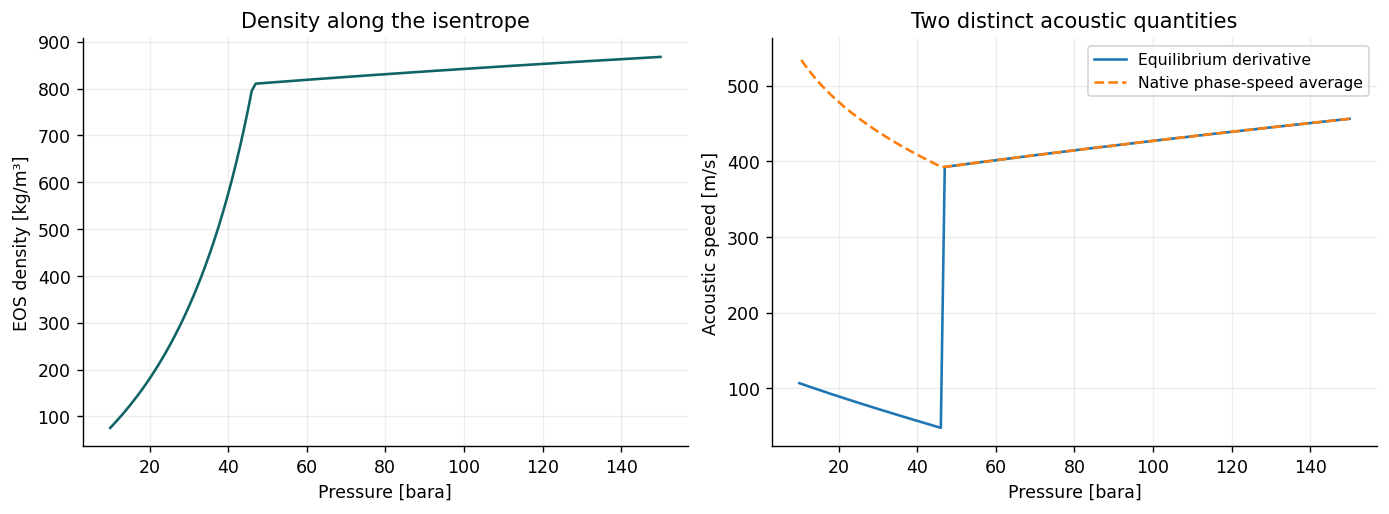

,P_bara,phases,c_eq_m_s,phase_average_m_s
0,150.0,1,456.226,456.226
50,100.0,1,427.082,427.082
100,50.0,1,394.720,394.720
110,40.0,2,57.082,408.758
130,20.0,2,89.374,478.517
140,10.0,2,106.905,538.038


In [7]:
def equilibrium_sound(base, pressure_bara, delta_bar=0.01):
    low = isentropic_state(base, pressure_bara - delta_bar)
    high = isentropic_state(base, pressure_bara + delta_bar)
    density_change = eos_density(high) - eos_density(low)
    assert np.isfinite(density_change) and density_change > 0.0
    return np.sqrt(2.0 * delta_bar * 1e5 / density_change)


pure_path["c_eq_m_s"] = [equilibrium_sound(pure_base, p) for p in pressures]
pure_path["phase_average_m_s"] = [fluid.getSoundSpeed() for fluid in pure_states]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(pressures, pure_path.rho_kg_m3, color="#116466")
axes[0].set(
    xlabel="Pressure [bara]", ylabel="EOS density [kg/m³]", title="Density along the isentrope"
)
axes[1].plot(pressures, pure_path.c_eq_m_s, label="Equilibrium derivative")
axes[1].plot(pressures, pure_path.phase_average_m_s, "--", label="Native phase-speed average")
axes[1].set(
    xlabel="Pressure [bara]",
    ylabel="Acoustic speed [m/s]",
    title="Two distinct acoustic quantities",
)
axes[1].legend(fontsize=9)
plt.show()
acoustic_comparison = pure_path.loc[
    pure_path.P_bara.isin([150, 100, 50, 40, 20, 10]),
    ["P_bara", "phases", "c_eq_m_s", "phase_average_m_s"],
]
display(acoustic_comparison.round(3))

## 7. From thermodynamic states to a decompression characteristic

Take distance positive into the intact pipe, away from the opening. Fluid velocity points toward the opening and is therefore negative; define its positive magnitude as $u$. For an inviscid, isentropic simple wave starting from rest, the Riemann invariant gives:

$$u(p)=\int_p^{p_0}\frac{\mathrm{d}p'}{\rho(p')c_{\mathrm{eq}}(p')}$$

$$w(p)=c_{\mathrm{eq}}(p)-u(p)$$

The laboratory-frame characteristic speed $w$ is in m/s. It differs from both the acoustic speed relative to the fluid and the fluid discharge speed. Positive $w$ travels into the intact pipe; negative $w$ does not. The first formula is integrated with descending pressure, with its sign explicitly accounted for.

This is the **fluid-side decompression characteristic** used to reason about competition with fracture propagation. No crack-speed curve is supplied: inventing one could imply an unsupported arrest prediction. A crack-speed/resistance relation must come from a qualified structural model or measurements. A pressure plateau or a phase-transition speed drop does not, on its own, determine arrest.

Equilibrium phase transitions can introduce sharp changes and non-monotonic characteristic curves. We plot the calculated curve directly and do not invert it into pressure–time traces. A valid finite-pipe rupture solution needs an appropriate wave/relaxation model and boundary conditions.

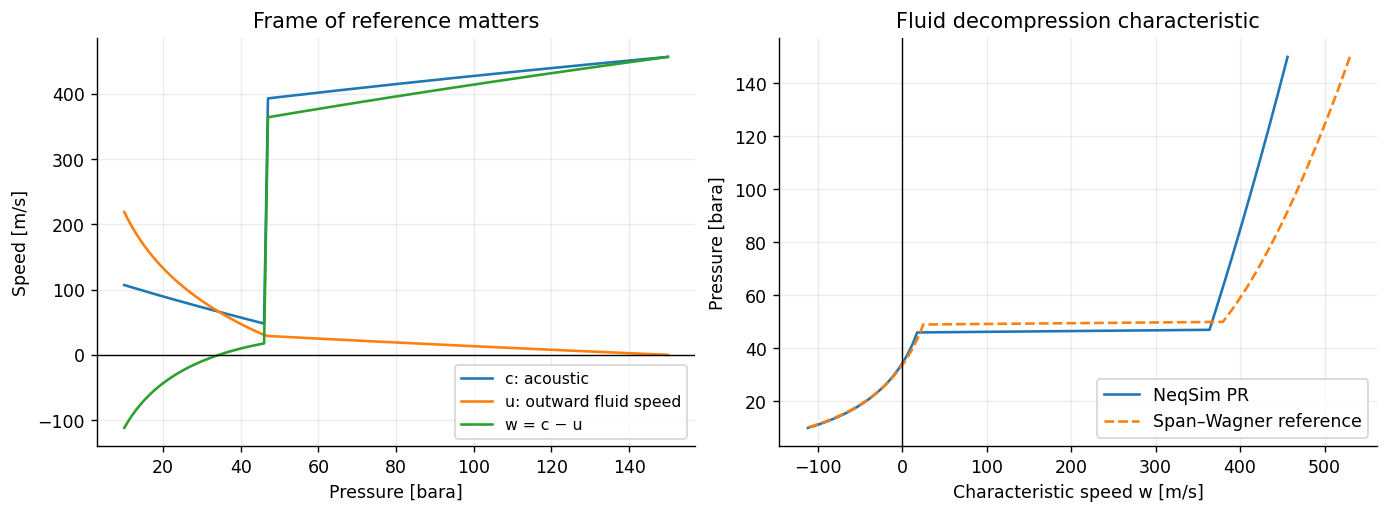

In [8]:
def add_wave_columns(path):
    result = path.copy()
    integrand = 1.0 / (result.rho_kg_m3.to_numpy() * result.c_eq_m_s.to_numpy())
    result["u_m_s"] = -cumulative_trapezoid(
        integrand,
        result.P_bara.to_numpy() * 1e5,
        initial=0.0,
    )
    result["w_m_s"] = result.c_eq_m_s - result.u_m_s
    return result


pure_path = add_wave_columns(pure_path)
reference_density_path = np.array(
    [PropsSI("Dmass", "P", p * 1e5, "Smass", reference_entropy, "HEOS::CO2") for p in pressures]
)
reference_sound_path = []
for pressure in pressures:
    density_low = PropsSI(
        "Dmass", "P", (pressure - 0.01) * 1e5, "Smass", reference_entropy, "HEOS::CO2"
    )
    density_high = PropsSI(
        "Dmass", "P", (pressure + 0.01) * 1e5, "Smass", reference_entropy, "HEOS::CO2"
    )
    reference_sound_path.append(np.sqrt(2000.0 / (density_high - density_low)))
reference_path = add_wave_columns(
    pd.DataFrame(
        {
            "P_bara": pressures,
            "rho_kg_m3": reference_density_path,
            "c_eq_m_s": reference_sound_path,
            "T_C": reference_temperature,
        }
    )
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(pressures, pure_path.c_eq_m_s, label="c: acoustic")
axes[0].plot(pressures, pure_path.u_m_s, label="u: outward fluid speed")
axes[0].plot(pressures, pure_path.w_m_s, label="w = c − u")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(xlabel="Pressure [bara]", ylabel="Speed [m/s]", title="Frame of reference matters")
axes[0].legend(fontsize=9)
axes[1].plot(pure_path.w_m_s, pressures, label="NeqSim PR")
axes[1].plot(reference_path.w_m_s, pressures, "--", label="Span–Wagner reference")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(
    xlabel="Characteristic speed w [m/s]",
    ylabel="Pressure [bara]",
    title="Fluid decompression characteristic",
)
axes[1].legend()
plt.show()

## 8. Impurities: flash redistribution and changes to the characteristic

The fluid in this section remains a closed material element with fixed overall composition during expansion. The light components partition preferentially into the gas phase when two phases form. An open vessel with preferential gas withdrawal would follow a changing overall composition and requires a separate inventory balance.

$$z_i=\sum_{\alpha}\beta_{\alpha}x_{i,\alpha},\qquad E_i=\frac{y_i}{z_i}$$

Here $z_i$ is bulk mole fraction, $x_{i,\alpha}$ is component mole fraction in phase $\alpha$, $\beta_{\alpha}$ is the phase mole fraction, $y_i$ is the gas mole fraction and $E_i$ is enrichment. All are dimensionless. **Enrichment $y_i/z_i$ differs from the vapor–liquid K-value $y_i/x_i$.** Values are undefined where a gas phase is absent; we retain missing values rather than convert them to zero.

`ImpurityMonitor` reads named NeqSim streams. No concentration alarm threshold is interpreted as a fracture-arrest criterion.

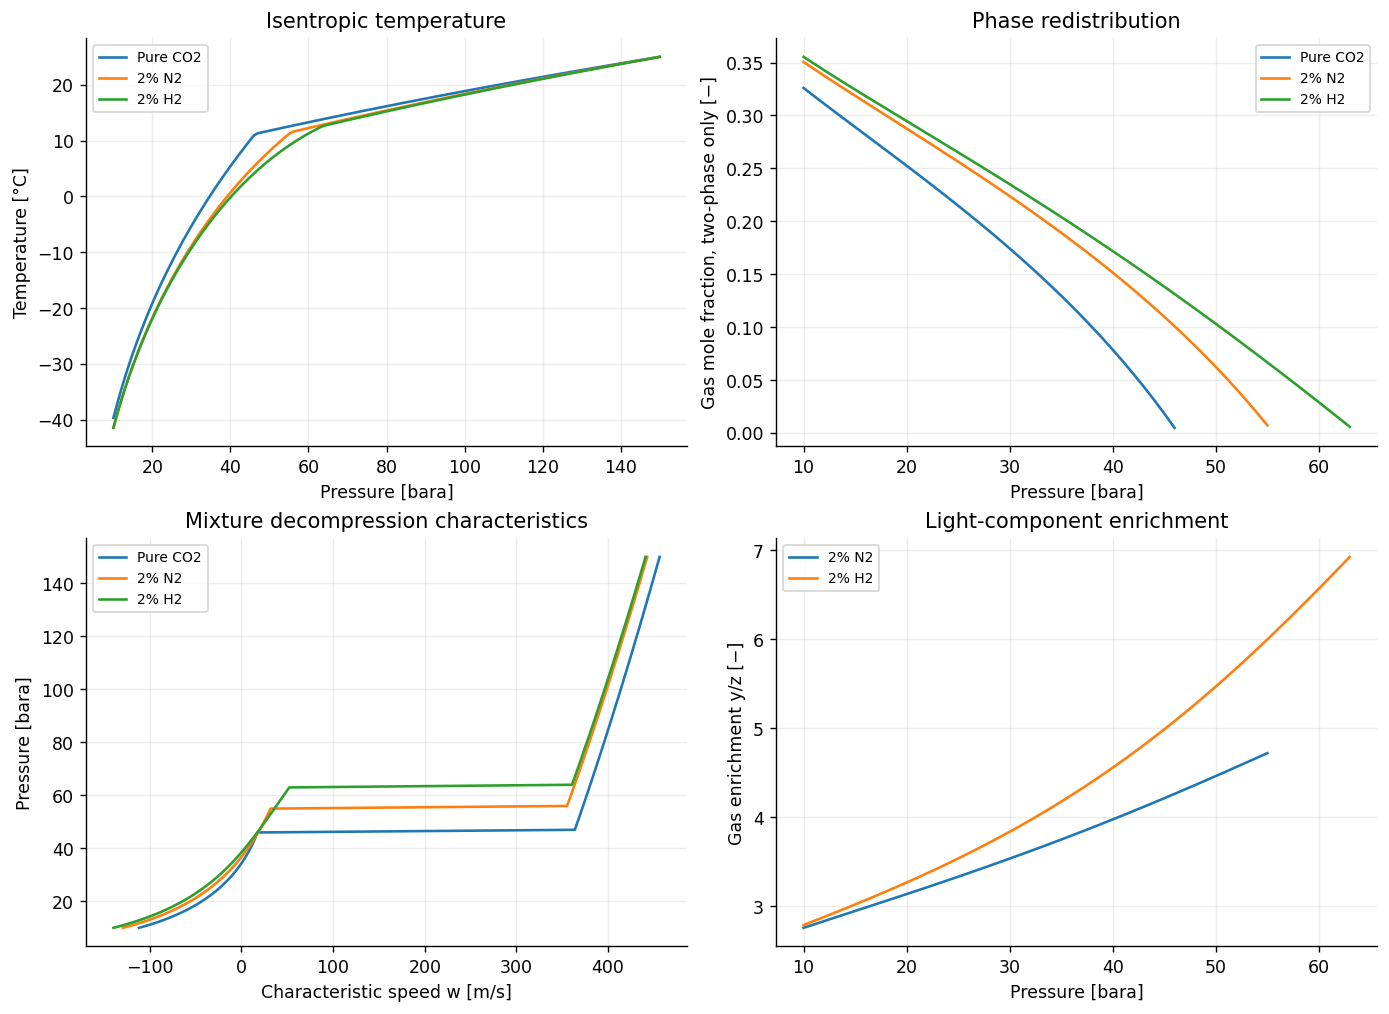

In [9]:
paths = {"Pure CO2": pure_path}
state_sets = {"Pure CO2": pure_states}
material_residuals = []
for name, base in initial_fluids.items():
    if name == "Pure CO2":
        continue
    states = [isentropic_state(base, pressure) for pressure in pressures]
    path = pd.DataFrame([snapshot(fluid) for fluid in states])
    path["c_eq_m_s"] = [equilibrium_sound(base, pressure) for pressure in pressures]
    paths[name] = add_wave_columns(path)
    state_sets[name] = states

impurity_rows = []
for name, states in state_sets.items():
    for fluid in states:
        beta_sum = sum(fluid.getBeta(k) for k in range(fluid.getNumberOfPhases()))
        assert abs(beta_sum - 1.0) < 1e-8
        for component in compositions[name]:
            reconstructed = sum(
                fluid.getBeta(k) * fluid.getPhase(k).getComponent(component).getx()
                for k in range(fluid.getNumberOfPhases())
            )
            material_residuals.append(abs(reconstructed - compositions[name][component]))
        if name != "Pure CO2":
            impurity = "nitrogen" if name == "2% N2" else "hydrogen"
            sample_stream = Stream(f"{name} equilibrium sample", fluid)
            monitor = ImpurityMonitor(f"{name} monitor", sample_stream)
            monitor.addTrackedComponent(impurity)
            impurity_rows.append(
                {
                    "Case": name,
                    "P_bara": fluid.getPressure(),
                    "gas_y": (
                        monitor.getGasPhaseMoleFraction(impurity)
                        if fluid.getNumberOfPhases() > 1
                        else np.nan
                    ),
                    "enrichment": (
                        monitor.getEnrichmentFactor(impurity)
                        if fluid.getNumberOfPhases() > 1
                        else np.nan
                    ),
                }
            )
impurity_table = pd.DataFrame(impurity_rows)
check("Flash component closure", max(material_residuals) < 1e-7, max(material_residuals))
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for name, path in paths.items():
    axes[0, 0].plot(path.P_bara, path.T_C, label=name)
    axes[0, 1].plot(path.P_bara, path.gas_mol_fraction, label=name)
    axes[1, 0].plot(path.w_m_s, path.P_bara, label=name)
for name, group in impurity_table.groupby("Case", sort=False):
    axes[1, 1].plot(group.P_bara, group.enrichment, label=name)
axes[0, 0].set(
    xlabel="Pressure [bara]", ylabel="Temperature [°C]", title="Isentropic temperature"
)
axes[0, 1].set(
    xlabel="Pressure [bara]",
    ylabel="Gas mole fraction, two-phase only [−]",
    title="Phase redistribution",
)
axes[1, 0].set(
    xlabel="Characteristic speed w [m/s]",
    ylabel="Pressure [bara]",
    title="Mixture decompression characteristics",
)
axes[1, 1].set(
    xlabel="Pressure [bara]", ylabel="Gas enrichment y/z [−]", title="Light-component enrichment"
)
for axis in axes.flat:
    axis.legend(fontsize=8)
plt.show()

## 9. Temperature and nitrogen sensitivity: locate phase entry with a bracket

Start each case at 150 bara. Follow its own isentrope and locate the first two-phase state while reducing pressure. This is an **isentropic phase-entry pressure**, not the saturation pressure at the initial temperature, and not a measured burst-test plateau pressure.

A 5-bar coarse scan locates a change from one phase to two. Bisection attempts to narrow the phase-count transition to 0.05 bar. If an intermediate flash fails its entropy check, refinement stops and the wider interval between the last verified endpoints is retained and explicitly reported. The H₂ summary case exercises this limitation near phase entry; no rejected intermediate state is used as a bound. We report both bounds; this resolution is numerical, not thermodynamic accuracy. Critical-region robustness and metastable phase delay require separate evaluation. The three initial temperatures and four nitrogen concentrations below are selected for teaching.

,Initial_T_C,N2_mol_pct,two_phase_bound_bara,one_phase_bound_bara,entry_midpoint_bara
0,10.0,0.0,33.867,33.906,33.887
1,10.0,1.0,39.023,39.062,39.043
2,10.0,2.0,44.141,44.180,44.160
3,10.0,3.0,49.102,49.141,49.121
4,25.0,0.0,46.328,46.367,46.348
5,25.0,1.0,51.016,51.055,51.035
6,25.0,2.0,55.586,55.625,55.605
7,25.0,3.0,60.000,60.039,60.020
8,35.0,0.0,55.391,55.430,55.410
9,35.0,1.0,59.609,59.648,59.629


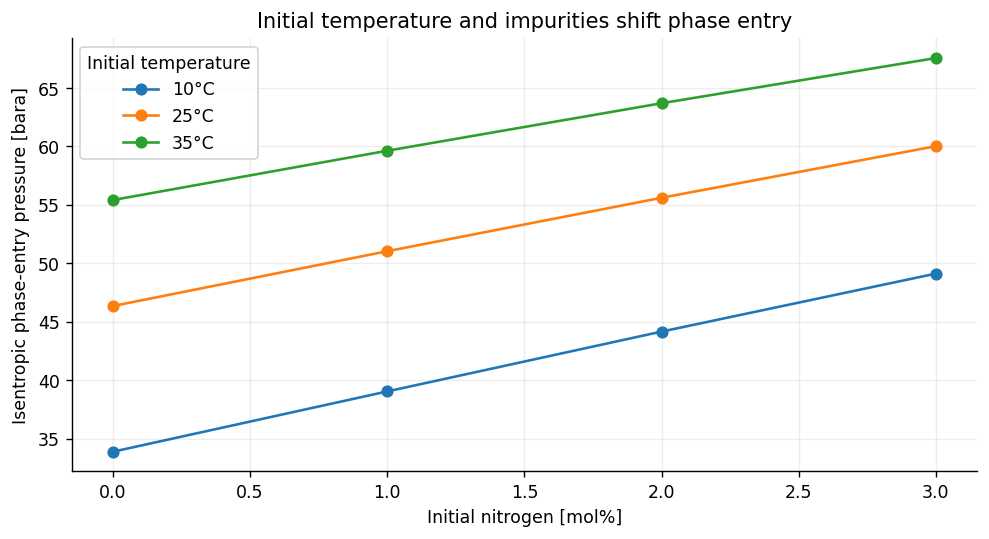

In [10]:
phase_entry_diagnostics = []


def phase_entry_bracket(base):
    upper = 150.0
    for pressure in np.arange(145.0, 9.9, -5.0):
        state = isentropic_state(base, pressure)
        if state.getNumberOfPhases() > 1:
            lower = float(pressure)
            break
        upper = float(pressure)
    else:
        raise ValueError("No two-phase entry in the tested pressure window")
    while upper - lower > 0.05:
        middle = 0.5 * (lower + upper)
        try:
            middle_state = isentropic_state(base, middle)
        except AssertionError as error:
            phase_entry_diagnostics.append(
                {
                    "attempted_P_bara": middle,
                    "verified_low_bara": lower,
                    "verified_high_bara": upper,
                    "rejected_entropy_residual": str(error),
                    "status": "Stopped; wider interval retained",
                }
            )
            break
        if middle_state.getNumberOfPhases() > 1:
            lower = middle
        else:
            upper = middle
    return lower, upper


sensitivity_rows = []
for temperature_c in [10.0, 25.0, 35.0]:
    for nitrogen_fraction in [0.0, 0.01, 0.02, 0.03]:
        composition = {"CO2": 1.0}
        if nitrogen_fraction > 0:
            composition = {"CO2": 1.0 - nitrogen_fraction, "nitrogen": nitrogen_fraction}
        base = make_fluid(composition, temperature_c)
        lower, upper = phase_entry_bracket(base)
        sensitivity_rows.append(
            {
                "Initial_T_C": temperature_c,
                "N2_mol_pct": 100 * nitrogen_fraction,
                "two_phase_bound_bara": lower,
                "one_phase_bound_bara": upper,
                "entry_midpoint_bara": 0.5 * (lower + upper),
            }
        )
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(3))
fig, axis = plt.subplots(figsize=(7.8, 4.2), constrained_layout=True)
for temperature, group in sensitivity.groupby("Initial_T_C"):
    axis.plot(group.N2_mol_pct, group.entry_midpoint_bara, "o-", label=f"{temperature:g}°C")
axis.set(
    xlabel="Initial nitrogen [mol%]",
    ylabel="Isentropic phase-entry pressure [bara]",
    title="Initial temperature and impurities shift phase entry",
)
axis.legend(title="Initial temperature")
plt.show()

## 10. Pressure loading, diameter and wall thickness

For a closed, thin-walled cylinder, a membrane hoop-stress scale is:

$$\sigma_\theta\approx\frac{(p_{\mathrm{inside}}-p_{\mathrm{outside}})D_m}{2t}$$

$D_m=D_o-t$ is mean diameter in m, $D_o$ is outer diameter in m, $t$ is wall thickness in m and pressure difference is Pa; stress is Pa. We convert the plotted result to MPa. We use an external pressure of 1 bara, representing an onshore atmospheric boundary. Subsea external pressure changes the differential load.

This is an elastic load scale for an intact pipe. A running crack changes geometry and unloading, and the steel response may be plastic. Yield strength, toughness, strain rate, temperature, crack-tip opening, backfill and fluid–structure interaction are absent. **No arrest/no-arrest result is calculated.**

At fixed thickness/diameter ratio this simple stress expression is independent of absolute diameter. By contrast, the fluid inventory per length scales with the square of inner diameter. That explains why diameter cannot be removed from a coupled fracture study merely because membrane stress looks similar.

,OD_m,t_over_OD,wall_mm,initial_hoop_MPa,initial_inventory_kg_m
0,0.610,0.015,9.150,489.217,238.566
1,0.610,0.020,12.200,365.050,233.673
2,0.610,0.025,15.250,290.550,228.830
3,0.914,0.015,13.716,489.217,536.070
4,0.914,0.020,18.288,365.050,525.074
5,0.914,0.025,22.860,290.550,514.192
6,1.219,0.015,18.288,489.217,953.013
7,1.219,0.020,24.384,365.050,933.465
8,1.219,0.025,30.480,290.550,914.119


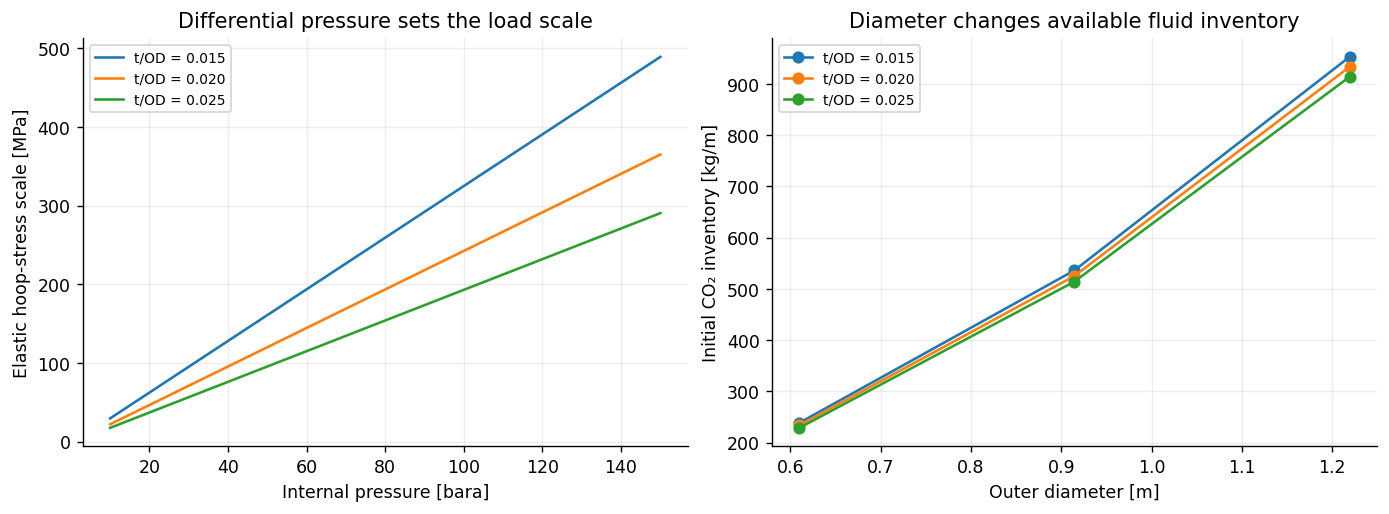

In [11]:
outer_diameters = [0.610, 0.9144, 1.2192]
thickness_ratios = [0.015, 0.020, 0.025]
external_bara = 1.0
geometry_rows = []
for diameter in outer_diameters:
    for ratio in thickness_ratios:
        thickness = ratio * diameter
        inner_diameter = diameter - 2 * thickness
        stress_mpa = (
            (150.0 - external_bara) * 1e5 * (diameter - thickness) / (2 * thickness) / 1e6
        )
        inventory_per_m = eos_density(pure_base) * np.pi * inner_diameter**2 / 4
        geometry_rows.append(
            {
                "OD_m": diameter,
                "t_over_OD": ratio,
                "wall_mm": thickness * 1000,
                "initial_hoop_MPa": stress_mpa,
                "initial_inventory_kg_m": inventory_per_m,
            }
        )
geometry_table = pd.DataFrame(geometry_rows)
display(geometry_table.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ratio in thickness_ratios:
    stress = (pressures - external_bara) * 1e5 * (1 - ratio) / (2 * ratio) / 1e6
    axes[0].plot(pressures, stress, label=f"t/OD = {ratio:.3f}")
for ratio, group in geometry_table.groupby("t_over_OD"):
    axes[1].plot(group.OD_m, group.initial_inventory_kg_m, "o-", label=f"t/OD = {ratio:.3f}")
axes[0].set(
    xlabel="Internal pressure [bara]",
    ylabel="Elastic hoop-stress scale [MPa]",
    title="Differential pressure sets the load scale",
)
axes[1].set(
    xlabel="Outer diameter [m]",
    ylabel="Initial CO₂ inventory [kg/m]",
    title="Diameter changes available fluid inventory",
)
for axis in axes:
    axis.legend(fontsize=8)
plt.show()

## 11. A composable process handoff and the suggested wellbore API

Named streams allow these states to be reused in larger NeqSim models. The two-phase sample below is generated from the accepted 2% N₂ isentrope at 40 bara. `ProcessSystem` re-runs its TP equilibrium, and the monitor reports the gas concentration.

This replay tests a useful integration boundary: the independently calculated equilibrium sample should retain its phase split and composition when passed to a process object. It is a thermodynamic sample, not a flow-connected rupture process or a simulation of mass discharged from a pipeline.

In [12]:
sample_fluid = isentropic_state(initial_fluids["2% N2"], 40.0)
sample_stream = Stream("decompression equilibrium handoff", sample_fluid.clone())
sample_stream.setFlowRate(1.0, "kg/sec")
process = ProcessSystem()
process.add(sample_stream)
process.run()
monitor = ImpurityMonitor("nitrogen in flashed CO2", sample_stream)
monitor.addTrackedComponent("nitrogen")
replayed = sample_stream.getThermoSystem()
replay_entropy_error = replayed.getEntropy("J/kgK") - sample_fluid.getEntropy("J/kgK")
check(
    "ProcessSystem state replay",
    abs(replay_entropy_error) < ENTROPY_TOLERANCE,
    replay_entropy_error,
)
display(
    pd.DataFrame(
        [
            {
                "Stream": sample_stream.getName(),
                "P_bara": sample_stream.getPressure(),
                "T_C": sample_stream.getTemperature("C"),
                "phases": replayed.getNumberOfPhases(),
                "gas_N2_mol_pct": 100 * monitor.getGasPhaseMoleFraction("nitrogen"),
                "enrichment_y_over_z": monitor.getEnrichmentFactor("nitrogen"),
            }
        ]
    )
)

,Stream,P_bara,T_C,phases,gas_N2_mol_pct,enrichment_y_over_z
0,decompression equilibrium handoff,40.0,0.69526,2,7.94981,3.97491


### What `TransientWellbore` actually computes in this version

Source inspection shows exponential relaxation toward a specified linear formation-temperature profile, a prescribed wellhead pressure decline, and a hydrostatic pressure contribution based on the initial density. `setShutdownCoolingRate` takes a **time constant in hours**, despite its name. The model does not solve conservation equations for a pipe rupture, finite-rate vaporization or crack propagation.

$$T(z,t)=T_f(z)+[T(z,0)-T_f(z)]\exp(-t/\tau)$$

Here depth $z$ is in m, time $t$ and time constant $\tau$ are in hours, and temperatures are K. We execute a 12-hour illustration and compare every returned temperature with that analytical law. We independently re-flash every reported P–T state because the inspected API catches flash failures internally without exposing a per-point convergence status. Only the checked states in this example are accepted.

`CO2InjectionWellAnalyzer` adds steady well calculations and coarse phase/enrichment scans. Its method `isSafeToOperate()` must not be read as a fracture-arrest acceptance result. The high-level analyzer is mapped here but not executed or validated against the paper.

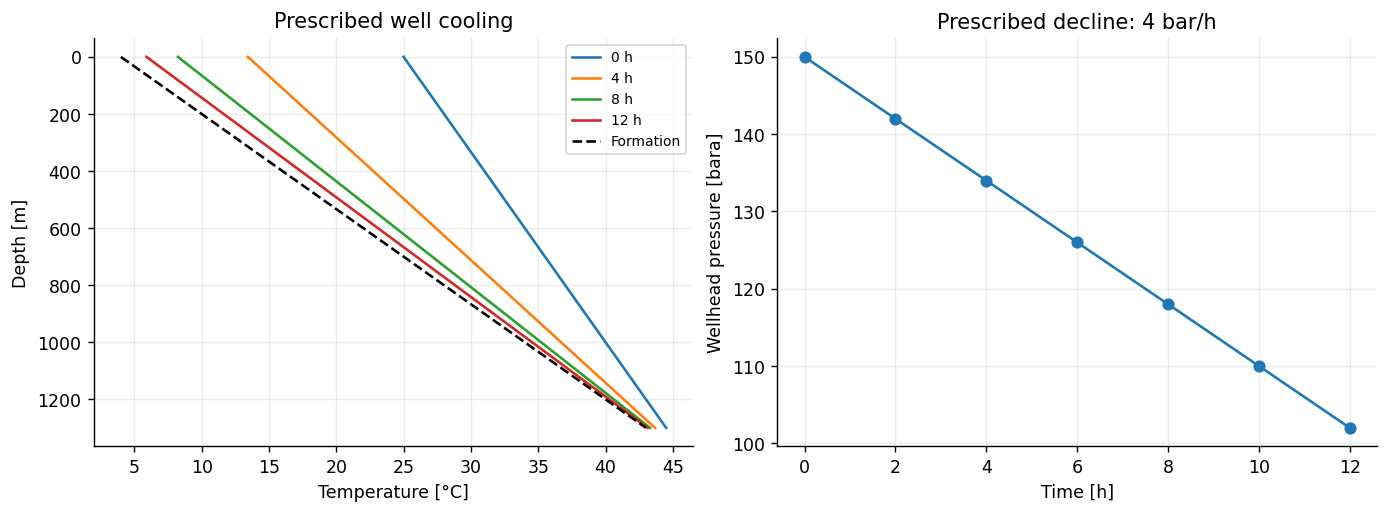

In [13]:
well_feed = Stream("synthetic injection feed", initial_fluids["2% N2"].clone())
well_feed.setFlowRate(10.0, "kg/sec")
well_feed.run()
well = TransientWellbore("prescribed shutdown illustration", well_feed)
well.setWellDepth(1300.0)
well.setTubingDiameter(0.1571)
well.setNumberOfSegments(10)
well.setFormationTemperature(277.15, 316.15)
well.setShutdownCoolingRate(5.0)
well.setDepressurizationRate(4.0)
well.runShutdownSimulation(12.0, 2.0)
well_snapshots = list(well.getSnapshots())
well_times = np.array([snap.timeHours for snap in well_snapshots])
well_depths = np.array(well_snapshots[0].depths)
well_temperature = np.array([list(snap.temperatures) for snap in well_snapshots])
formation_temperature = 277.15 + (316.15 - 277.15) * well_depths / 1300.0
analytic_temperature = formation_temperature + (
    well_temperature[0] - formation_temperature
) * np.exp(-well_times[:, None] / 5.0)
max_temperature_error = np.max(np.abs(well_temperature - analytic_temperature))
check("Well cooling analytical law", max_temperature_error < 1e-10, max_temperature_error)
for snap in well_snapshots:
    for index, temperature in enumerate(snap.temperatures):
        trial = initial_fluids["2% N2"].clone()
        trial.setTemperature(float(temperature))
        trial.setPressure(float(snap.pressures[index]))
        ThermoOps(trial).TPflash()
        trial.init(3)
        assert trial.getNumberOfPhases() == snap.numberOfPhases[index]
        if trial.getNumberOfPhases() > 1:
            assert abs(snapshot(trial)["gas_mol_fraction"] - snap.gasFraction[index]) < 1e-7
check("Well snapshot phase audit", True, f"{well_temperature.size} independent TP replays")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for index in [0, 2, 4, 6]:
    axes[0].plot(well_temperature[index] - 273.15, well_depths, label=f"{well_times[index]:g} h")
axes[0].plot(formation_temperature - 273.15, well_depths, "k--", label="Formation")
axes[0].invert_yaxis()
axes[0].set(xlabel="Temperature [°C]", ylabel="Depth [m]", title="Prescribed well cooling")
axes[0].legend(fontsize=8)
axes[1].plot(well_times, [snap.pressures[0] for snap in well_snapshots], "o-")
axes[1].set(
    xlabel="Time [h]", ylabel="Wellhead pressure [bara]", title="Prescribed decline: 4 bar/h"
)
plt.show()

## 12. Verification and numerical sensitivity

A successful Java call is not sufficient evidence. We separately check material closure, entropy closure, single-phase derivative consistency, finite-difference sensitivity and pressure-grid integration. The independent ideal-gas solution tests the wave integral's units and sign convention:

$$c(p)=c_0\left(\frac{p}{p_0}\right)^{(\gamma-1)/(2\gamma)},\qquad u(p)=\frac{2(c_0-c)}{\gamma-1}$$

Here $\gamma$ is the ideal-gas heat-capacity ratio, $c_0$ is initial acoustic speed and pressure units must be consistent. This analytic test verifies the integral implementation; it does not validate the CO₂ EOS.

Derivative checks use 100 and 40 bara, away from the baseline pure-CO₂ phase-entry boundary. The pressure-grid test refines only the integral using additional calculated states. We retain coarse/fine differences as uncertainty evidence. A grid-dependent characteristic near phase entry is a reason to refine or use event-aware integration, not to tune a fracture curve.

In [14]:
all_entropy_errors = [
    abs(state.getEntropy("J/kgK") - initial_fluids[name].getEntropy("J/kgK"))
    for name, states in state_sets.items()
    for state in states
]
check(
    "All accepted path entropy residuals",
    max(all_entropy_errors) < ENTROPY_TOLERANCE,
    max(all_entropy_errors),
)
fd_rows = []
for name, base in initial_fluids.items():
    for pressure in [100.0, 40.0]:
        values = [equilibrium_sound(base, pressure, delta) for delta in [0.005, 0.01, 0.02]]
        spread = 100 * (max(values) - min(values)) / np.mean(values)
        fd_rows.append(
            {
                "Case": name,
                "P_bara": pressure,
                "c_0.005": values[0],
                "c_0.01": values[1],
                "c_0.02": values[2],
                "spread_pct": spread,
            }
        )
fd_table = pd.DataFrame(fd_rows)
check(
    "Acoustic finite-difference sensitivity",
    fd_table.spread_pct.max() < 1.0,
    fd_table.spread_pct.max(),
)
display(fd_table.round(5))
single_phase_errors = []
for name, path in paths.items():
    for pressure in [150.0, 100.0]:
        state = isentropic_state(initial_fluids[name], pressure)
        assert state.getNumberOfPhases() == 1
        fd_speed = equilibrium_sound(initial_fluids[name], pressure)
        single_phase_errors.append(abs(fd_speed / state.getSoundSpeed() - 1.0))
check(
    "Single-phase analytic/FD sound agreement",
    max(single_phase_errors) < 1e-4,
    max(single_phase_errors),
)

ideal_gamma = 1.3
ideal_p = np.linspace(150e5, 10e5, 4001)
ideal_rho0 = 150.0
ideal_c0 = np.sqrt(ideal_gamma * ideal_p[0] / ideal_rho0)
ideal_rho = ideal_rho0 * (ideal_p / ideal_p[0]) ** (1 / ideal_gamma)
ideal_c = ideal_c0 * (ideal_p / ideal_p[0]) ** ((ideal_gamma - 1) / (2 * ideal_gamma))
ideal_u_numeric = -cumulative_trapezoid(1 / (ideal_rho * ideal_c), ideal_p, initial=0)
ideal_u_exact = 2 * (ideal_c0 - ideal_c) / (ideal_gamma - 1)
ideal_max_error = np.max(np.abs(ideal_u_numeric - ideal_u_exact))
check("Ideal-gas wave integral", ideal_max_error < 0.02, ideal_max_error)

fine_pressures = np.linspace(150.0, 10.0, 561)
fine_states = [isentropic_state(pure_base, p) for p in fine_pressures]
fine_path = pd.DataFrame([snapshot(state) for state in fine_states])
fine_path["c_eq_m_s"] = [equilibrium_sound(pure_base, p) for p in fine_pressures]
fine_path = add_wave_columns(fine_path)
wave_grid_error = np.max(np.abs(fine_path.u_m_s.to_numpy()[::4] - pure_path.u_m_s))
check("Pure-CO2 wave quadrature: 1 to 0.25 bar", wave_grid_error < 2.0, wave_grid_error)
check(
    "Minimum accepted fluid temperature above 220 K",
    min(path.T_C.min() + 273.15 for path in paths.values()) > 220.0,
    min(path.T_C.min() + 273.15 for path in paths.values()),
)
display(pd.DataFrame(checks))

,Case,P_bara,c_0.005,c_0.01,c_0.02,spread_pct
0,Pure CO2,100.0,427.08173,427.08173,427.08173,0.00000
1,Pure CO2,40.0,57.08172,57.08172,57.08172,0.00001
2,2% N2,100.0,412.67381,412.67381,412.67381,0.00000
3,2% N2,40.0,74.59184,74.59184,74.59184,0.00000
4,2% H2,100.0,410.58575,410.58575,410.58575,0.00000
5,2% H2,40.0,82.66232,82.66232,82.66232,0.00000


,Check,Result,Evidence
0,All starting fluids single phase,PASS,3
1,Mixture workaround entropy closure,PASS,-5.47106537851505e-09
2,Flash component closure,PASS,2.997793435710605e-08
3,ProcessSystem state replay,PASS,-1.3642420526593924e-12
4,Well cooling analytical law,PASS,5.684341886080802e-14
5,Well snapshot phase audit,PASS,77 independent TP replays
6,All accepted path entropy residuals,PASS,3.631871550169308e-07
7,Acoustic finite-difference sensitivity,PASS,1.3338797601098866e-05
8,Single-phase analytic/FD sound agreement,PASS,1.3157501754790246e-09
9,Ideal-gas wave integral,PASS,0.00018213277587619814


## 13. Results to carry into the next study

The table below is computed from the saved paths. It reports phase-entry bounds, minimum temperature, the equilibrium sound speed and wave characteristic at 40 bara, and the largest gas-phase impurity enrichment. The native phase-speed average is deliberately kept out of the wave calculation.

Read the results in three layers:

- **Numerical verification:** residual, material-balance, analytic-limit and refinement checks establish that the stated calculations are internally consistent within the reported tolerances.
- **Thermodynamic comparison:** the pure-CO₂ reference identifies EOS-dependent density, temperature and acoustic differences. It does not validate CO₂-mixture interaction parameters.
- **Fracture assessment:** pressure loading and fluid inventory are inputs to a structural calculation. They do not establish crack resistance, arrest distance or a minimum wall thickness.

In [15]:
summary_rows = []
for name, path in paths.items():
    lower, upper = phase_entry_bracket(initial_fluids[name])
    at_40 = path.loc[path.P_bara == 40.0].iloc[0]
    enrichment = np.nan
    if name != "Pure CO2":
        enrichment = impurity_table.loc[impurity_table.Case == name, "enrichment"].max()
    summary_rows.append(
        {
            "Case": name,
            "phase_entry_low_bar": lower,
            "phase_entry_high_bar": upper,
            "minimum_T_C": path.T_C.min(),
            "c_at_40_m_s": at_40.c_eq_m_s,
            "w_at_40_m_s": at_40.w_m_s,
            "max_enrichment": enrichment,
        }
    )
summary = pd.DataFrame(summary_rows)
display(summary.round(3))
if phase_entry_diagnostics:
    print("Phase-entry refinements that stopped at a wider verified bracket:")
    display(pd.DataFrame(phase_entry_diagnostics))
pr_reference = reference_table.loc[reference_table.EOS == "PR"]
print(
    f"PR maximum absolute density deviation on the six reference states: "
    f"{pr_reference.rho_error_pct.abs().max():.2f}%"
)
print(
    f"PR maximum absolute acoustic deviation on the six reference states: "
    f"{pr_reference.c_error_pct.abs().max():.2f}%"
)
print(f"Largest accepted path entropy residual: {max(all_entropy_errors):.3e} J/(kg K)")
print(f"Pure-CO2 quadrature refinement difference: {wave_grid_error:.4f} m/s")
print(f"All {len(checks)} verification groups passed. No fracture-arrest qualification claimed.")

Phase-entry refinements that stopped at a wider verified bracket:
PR maximum absolute density deviation on the six reference states: 10.29%
PR maximum absolute acoustic deviation on the six reference states: 15.67%
Largest accepted path entropy residual: 3.632e-07 J/(kg K)
Pure-CO2 quadrature refinement difference: 0.3834 m/s
All 12 verification groups passed. No fracture-arrest qualification claimed.


,Case,phase_entry_low_bar,phase_entry_high_bar,minimum_T_C,c_at_40_m_s,w_at_40_m_s,max_enrichment
0,Pure CO2,46.328,46.367,-39.705,57.082,9.755,NaN
1,2% N2,55.586,55.625,-41.446,74.592,6.969,4.720
2,2% H2,63.438,63.594,-41.483,82.662,3.680,6.926


,attempted_P_bara,verified_low_bara,verified_high_bara,rejected_entropy_residual,status
0,63.51562,63.4375,63.59375,-0.2554154064346221,Stopped; wider interval retained


## 14. How to turn this into a published-data benchmark

Obtain the full paper and its cited experimental records through an authorized source. The following data are needed before claiming a reproduction:

| Data group | Required fields | Comparison enabled |
|---|---|---|
| Fluid and initial condition | Full mole composition, water content, initial P/T profiles and uncertainties | EOS and initial-state reproducibility |
| Pipe | Outer diameter, thickness, length, roughness, welds, boundary conditions, burial/backfill | Geometry and transient loading |
| Fluid measurements | Sensor locations, synchronized pressure/temperature traces, calibration and bandwidth | Wave arrival, pressure plateau and depressurization rate |
| Steel and fracture | Stress–strain curves, temperature/rate dependence, toughness method, crack initiation and crack-position history | Crack speed, resistance and arrest location |
| Numerical model | EOS, heat transfer, friction, phase relaxation, mesh/time step, coupling and material damage law | Model-to-model reproduction |
| Provenance | DOI, table/figure IDs, license/permission, extraction method and uncertainty | Auditable reuse and digitization |

**Suggested comparison order:** (1) independent thermophysical checks, (2) fixed-wall decompression tests, (3) calibrated steel fracture tests, (4) coupled burst tests held out from calibration. Report arrival-time error, pressure-trace RMSE, plateau-pressure error, crack-speed error and arrest-location error separately. Select acceptance tolerances from measurement uncertainty and intended use before calibration.

The paper's statements about DNV RP F104 are part of its abstract. No current-standard clauses, safety factors or compliance calculations are implemented here. Use the applicable licensed standard and project basis for any design assessment.

### Current NeqSim improvements and limitations

- [#3751](https://github.com/equinor/neqsim/issues/3751): native mixture PS flash can return without entropy closure. The notebook's TP-root wrapper is explicit and verified; it is not a silent library repair.
- [#3750](https://github.com/equinor/neqsim/issues/3750): research scope remains open. Experimental validation and structural fracture modelling are still needed.
- The current system acoustic getter averages phase speeds. A reusable, explicitly named equilibrium acoustic API with closure and derivative diagnostics would remove duplicated notebook logic; this is tracked in [#3752](https://github.com/equinor/neqsim/issues/3752).
- The current wellbore model uses prescribed thermal/pressure histories; its snapshot flash failures are not reported individually. This notebook independently checks the demonstrated snapshots, but that is not a general qualification of the API.
- The 2% H₂ phase-entry refinement encounters a TP-root residual near the phase boundary. Its summary therefore retains a wider interval with valid endpoints, with the rejected residual shown; flash-stability work is tracked by [#2937](https://github.com/equinor/neqsim/issues/2937).
- HEM neglects metastability, delayed nucleation, phase slip, friction, wall/soil heat transfer and changing crack geometry. The 10-bara endpoint is not a model of the final atmospheric/solid-CO₂ release.

## 15. Reusable outputs and student/research exercises

All relevant tables and figures are embedded above. The final cell also writes CSV files and a JSON provenance/validation record into `co2_fracture_results/`, then creates a ZIP for reuse. These files are generated by running the notebook; they contain synthetic calculations, not publisher data.

1. Repeat the reference grid nearer the critical point. Which derivative changes most rapidly, and how does the EOS error change?
2. Refine the pressure grid around phase entry and compare characteristic speed convergence, keeping the finite-difference step independent of the integration grid.
3. Replace N₂ with a justified capture-stream mixture. Record binary-parameter provenance and identify missing experimental validation.
4. Compare frozen-composition and equilibrium acoustic models, deriving each closure before coding it. Do not substitute an average of phase sound speeds without a derivation.
5. Add measured fixed-wall decompression data, retain uncertainty, and separate calibration records from validation records.
6. Couple the fluid model to a calibrated structural solver. Explain why matching one pressure plateau does not validate arrest.

### References and related notebooks

1. Mondry, A.; Bosch, C. (2024). [IPC2024-132853](https://doi.org/10.1115/IPC2024-132853). Paper scope summarized from the publisher-deposited abstract; no paper tables or figures reproduced.
2. Span, R.; Wagner, W. (1996). [A new equation of state for carbon dioxide](https://doi.org/10.1063/1.555991), as implemented by [CoolProp HEOS](https://coolprop.org/fluid_properties/fluids/CarbonDioxide.html).
3. NeqSim [source revision used here](https://github.com/equinor/neqsim/tree/0852741babb7601304c70d10528e8de562bdf0be). See `SystemThermo`, `ThermodynamicOperations`, `TransientWellbore`, `CO2InjectionWellAnalyzer` and `ImpurityMonitor`.
4. [CO₂ low-temperature compression, relief and depressurization](../thermodynamics/CO2_low_temperature_compression_relief_and_depressurization.ipynb).
5. [CO₂ pipeline](CO2pipeline.ipynb) and [CO₂-rich mixture phase envelopes](../thermodynamics/phaseenvelopesofCO2richmixtures.ipynb).

**Documentation impact:** new educational workflow and examples navigation; no Java implementation changes. Validation applies to the pinned source and the cases shown, not to untested scenarios or a future master revision.

In [16]:
import shutil

output_directory = Path("co2_fracture_results")
output_directory.mkdir(exist_ok=True)
for name, path in paths.items():
    safe_name = {"Pure CO2": "pure_co2", "2% N2": "co2_nitrogen", "2% H2": "co2_hydrogen"}[name]
    path.to_csv(output_directory / f"{safe_name}_isentropic_path.csv", index=False)
for filename, table in [
    ("reference_eos_comparison.csv", reference_table),
    ("phase_entry_sensitivity.csv", sensitivity),
    ("impurity_enrichment.csv", impurity_table),
    ("geometry_loading.csv", geometry_table),
    ("summary.csv", summary),
    ("verification_checks.csv", pd.DataFrame(checks)),
    ("acoustic_finite_difference.csv", fd_table),
]:
    table.to_csv(output_directory / filename, index=False)
validation_record = {
    **provenance,
    "issue": "https://github.com/equinor/neqsim/issues/3750",
    "known_psflash_issue": "https://github.com/equinor/neqsim/issues/3751",
    "input_basis": "synthetic teaching cases; no paper numerical data used",
    "model": "PR, mixing rule 2, EOS volume without volume correction",
    "entropy_residual_max_J_kgK": max(all_entropy_errors),
    "component_residual_max": max(material_residuals),
    "wave_grid_refinement_max_m_s": float(wave_grid_error),
    "verification_groups_passed": len(checks),
    "fracture_arrest_qualified": False,
    "phase_entry_refinement_diagnostics": phase_entry_diagnostics,
    "packages": {
        item.split("==")[0]: metadata.version(item.split("==")[0])
        for item in requirements.values()
    },
}
(output_directory / "provenance_validation.json").write_text(
    json.dumps(validation_record, indent=2),
    encoding="utf-8",
)
archive = shutil.make_archive(str(output_directory), "zip", output_directory)
display(
    pd.DataFrame(
        [
            {"File": file.name, "Bytes": file.stat().st_size}
            for file in sorted(output_directory.iterdir())
        ]
    )
)
print("Created archive:", Path(archive).name)

Created archive: co2_fracture_results.zip


,File,Bytes
0,acoustic_finite_difference.csv,582
1,co2_hydrogen_isentropic_path.csv,20832
2,co2_nitrogen_isentropic_path.csv,20642
3,geometry_loading.csv,564
4,impurity_enrichment.csv,7422
5,phase_entry_sensitivity.csv,578
6,provenance_validation.json,1196
7,pure_co2_isentropic_path.csv,23089
8,reference_eos_comparison.csv,1527
9,summary.csv,377
